In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [25]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

In [26]:
# Decision Tree 
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Traning accuracy: ", accuracy_score(y_train, y_pred_train)* 100 , "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)* 100 , "%")

Traning accuracy:  97.91332263242376 %
Testing accuracy:  77.23880597014924 %


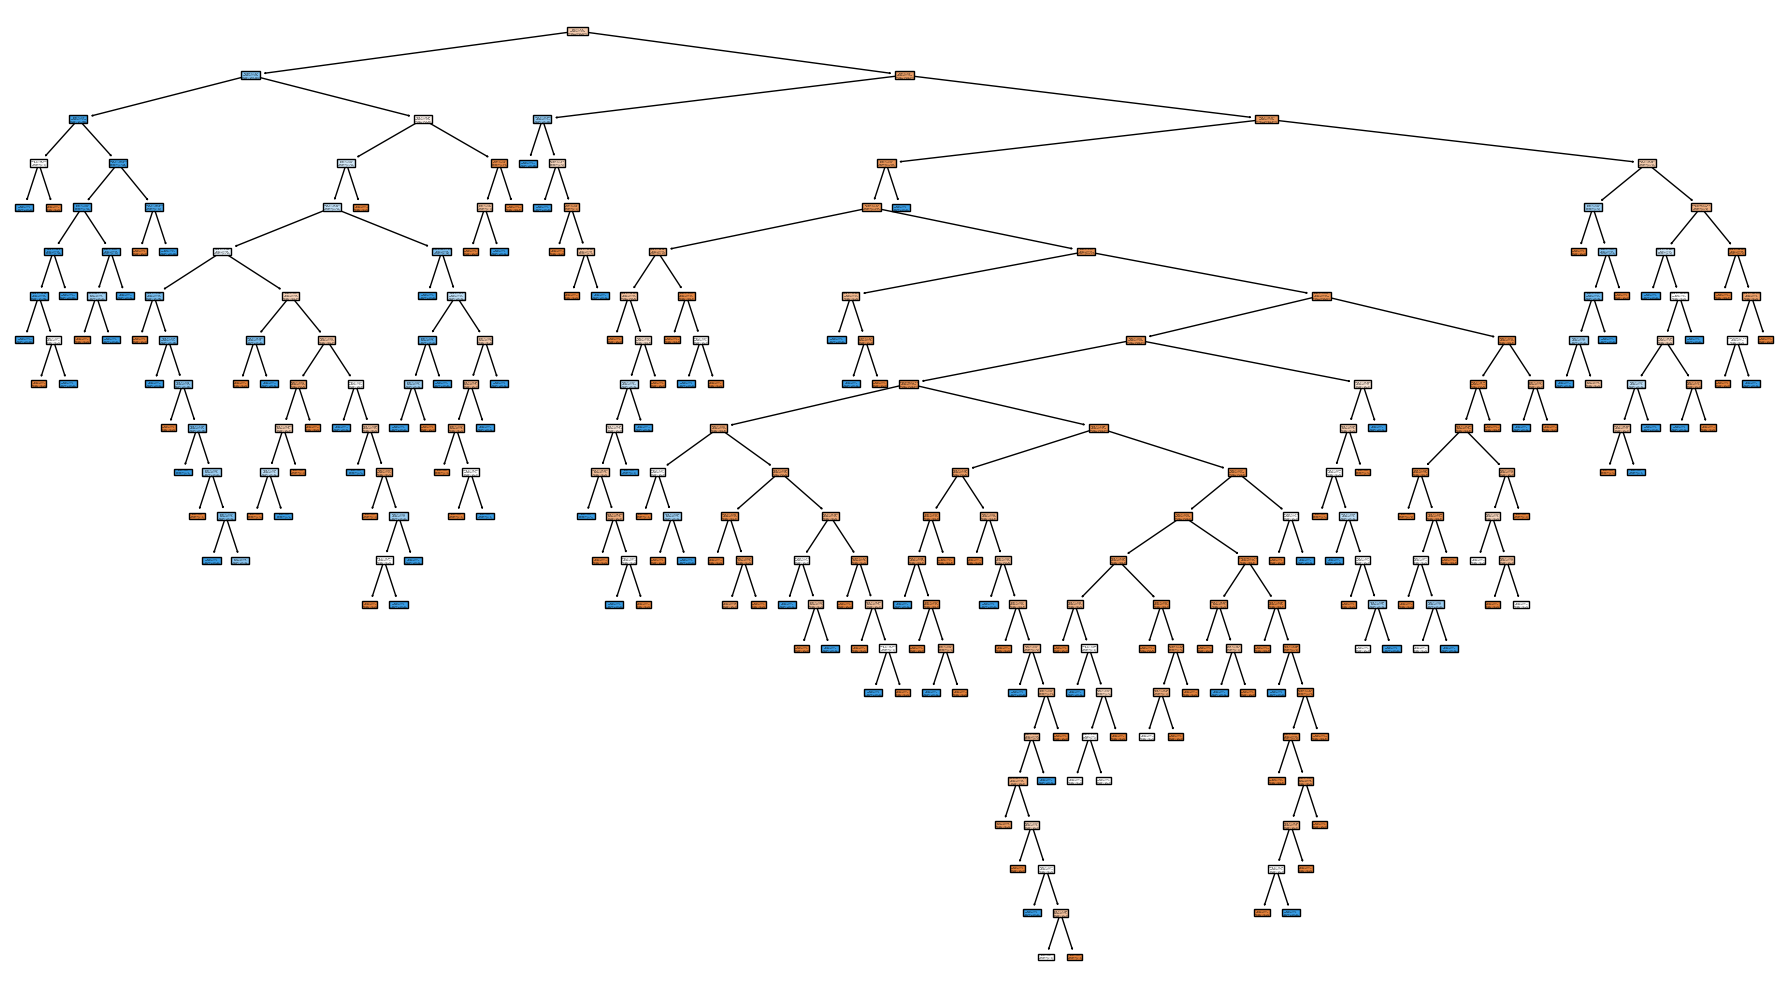

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)
plt.tight_layout()

In [28]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=401,
    oob_score=True
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_ * 100, "%")
print("testing accureacy: ", accuracy_score(y_test, y_pred) * 100, "%")

OOB score:  81.2199036918138 %
testing accureacy:  77.61194029850746 %


In [29]:
# Bagging Blassifier 

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7761194029850746


In [30]:
# Bagging Classifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7947761194029851
